In [10]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import uproot
import pandas as pd
import mplhep as hep
hep.style.use("CMS")

In [11]:
def get_limits(fn):
    f = uproot.open(fn)
    limit = f["limit"].get("limit").array().to_numpy()
    quant = f["limit"].get("quantileExpected").array().to_numpy()
    if limit.shape[0] == 1:
        return -1
    else:
        return np.stack([quant,limit])

In [12]:
eft_param_values = {
"m0p1" :-0.1, 
"m0p2" :-0.2,
"m0p3" :-0.3, 
"m0p5" :-0.5,
"m1"   :-1.0,
"m2"   :-2.0,
"m4"   :-4.0,
"m8"   :-8.0,
"m16"  :-16.0,
"m32"  :-32.0,
"m64"  :-64.0,
"m128" :-128.0,
"0p1"  : 0.1,
"0p2"  : 0.2,
"0p3"  : 0.3,
"0p5"  : 0.5,
"1"    : 1.0,
"2"    : 2.0,
"4"    : 4.0,
"8"    : 8.0, 
"16"   :16.0,
"32"   :32.0,
"64"   :64.0,
"128"  :128.0,
}

eft_param_values = dict(sorted(eft_param_values.items(), key=lambda x:x[1]))

def get_eft_limits(param='FT2'):
    data = pd.DataFrame(
        {
            "obs" : [],
            "exp" : [],
            "m1s" : [],
            "p1s" : [],
            "m2s" : [],
            "p2s" : [],
            "eft" : []
        }
    )
    limits = []
    eftval = []
    for name, value in eft_param_values.items():
        file_name = f"./EFTfit/higgsCombine{param}_{name}.AsymptoticLimits.mH125.root"
        res = get_limits(file_name)
        print('limit',param,'_',name,len(res),res)
        limits.append(res)
        eftval.append(value)
    #print(len(limits))
    for i in limits:
        print(len(i))
    limits = np.array(limits)
    eftval = np.array(eftval)
        
    print(limits.shape)
    data['obs'] = limits[:,1,5]
    data['exp'] = limits[:,1,2]
    data['m1s'] = limits[:,1,1]
    data['p1s'] = limits[:,1,3]
    data['m2s'] = limits[:,1,0]
    data['p2s'] = limits[:,1,4]
    data['eft'] = eftval
    
    return data
    

In [13]:
data = get_eft_limits()

limit FT2 _ m128 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.86752319  1.17794418  1.6953125   2.48595023  3.51819825  1.13711543]]
limit FT2 _ m64 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.871521    1.1898694   1.703125    2.49740624  3.53441119  1.13068324]]
limit FT2 _ m32 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.8835144   1.19965744  1.7265625   2.5180099   3.57460856  1.11263426]]
limit FT2 _ m16 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.93521118  1.25609469  1.7734375   2.55809617  3.58787799  1.12259286]]
limit FT2 _ m8 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.92697144  1.24502778  1.7578125   2.52154446  3.52528381  1.14809871]]
limit FT2 _ m4 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.98553467  1.32201385  1.8828125   2.7308743   3.84210849  

In [14]:
data

,obs,exp,m1s,p1s,m2s,p2s,eft
0,1.137115,1.695312,1.177944,2.485950,0.867523,3.518198,-128.0
1,1.130683,1.703125,1.189869,2.497406,0.871521,3.534411,-64.0
2,1.112634,1.726562,1.199657,2.518010,0.883514,3.574609,-32.0
3,1.122593,1.773438,1.256095,2.558096,0.935211,3.587878,-16.0
4,1.148099,1.757812,1.245028,2.521544,0.926971,3.525284,-8.0
5,0.996907,1.882812,1.322014,2.730874,0.985535,3.842108,-4.0
6,1.002734,1.875000,1.314468,2.734490,0.966797,3.858747,-2.0
7,1.012871,1.875000,1.311951,2.734490,0.974121,3.858747,-1.0
8,1.006225,1.882812,1.317417,2.730874,0.978180,3.853806,-0.5
9,1.006484,1.875000,1.311951,2.734490,0.974121,3.858747,-0.3


In [15]:
def plotting(param='FT1'):
    data = get_eft_limits(param)
    plt.fill_between(data.eft, data.m1s, data.p1s,
                     color="#00CC00", lw=0, label="68% expected")
    plt.fill_between(data.eft, data.m2s, data.p2s,
                     color="#FFCC01", lw=0, label="95% expected")
    plt.fill_between(data.eft, data.m1s, data.p1s,
                     color="#00CC00", lw=0)
    plt.plot(data.eft, data.exp, marker='.', ls="--", ms=0, color="blue", label="Median expected")
    # plt.plot(data.eft, data.obs, marker='.', ls="-", ms=0, color='black', label="Observed")
    plt.axhline(1, ls="--", color="red")
    #plt.xlabel(r"$S_{0}$ $m_{\rm med}$ [GeV]", x=1, ha='right')
    #plt.xlabel(r"$T_{8}$", x=1, ha='right')
    plt.ylabel(r"$95\%$ CL limit on $\sigma_{exp}/\sigma_{theo}$", y=1, ha='right')
    plt.title(f'{param}')
    plt.savefig(f'plot-{param}.png')
    # plt.ylim([0.1, 1e4])

In [16]:
paramlist=['FS0','FS1','FS2',
           'FM0','FM1','FM2','FM3','FM4','FM5','FM7',
           'FT1','FT2','FT3','FT4','FT5','FT6','FT7','FT8','FT9']

limit FT2 _ m128 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.86752319  1.17794418  1.6953125   2.48595023  3.51819825  1.13711543]]
limit FT2 _ m64 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.871521    1.1898694   1.703125    2.49740624  3.53441119  1.13068324]]
limit FT2 _ m32 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.8835144   1.19965744  1.7265625   2.5180099   3.57460856  1.11263426]]
limit FT2 _ m16 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.93521118  1.25609469  1.7734375   2.55809617  3.58787799  1.12259286]]
limit FT2 _ m8 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.92697144  1.24502778  1.7578125   2.52154446  3.52528381  1.14809871]]
limit FT2 _ m4 2 [[ 0.025       0.16        0.5         0.83999997  0.97500002 -1.        ]
 [ 0.98553467  1.32201385  1.8828125   2.7308743   3.84210849  

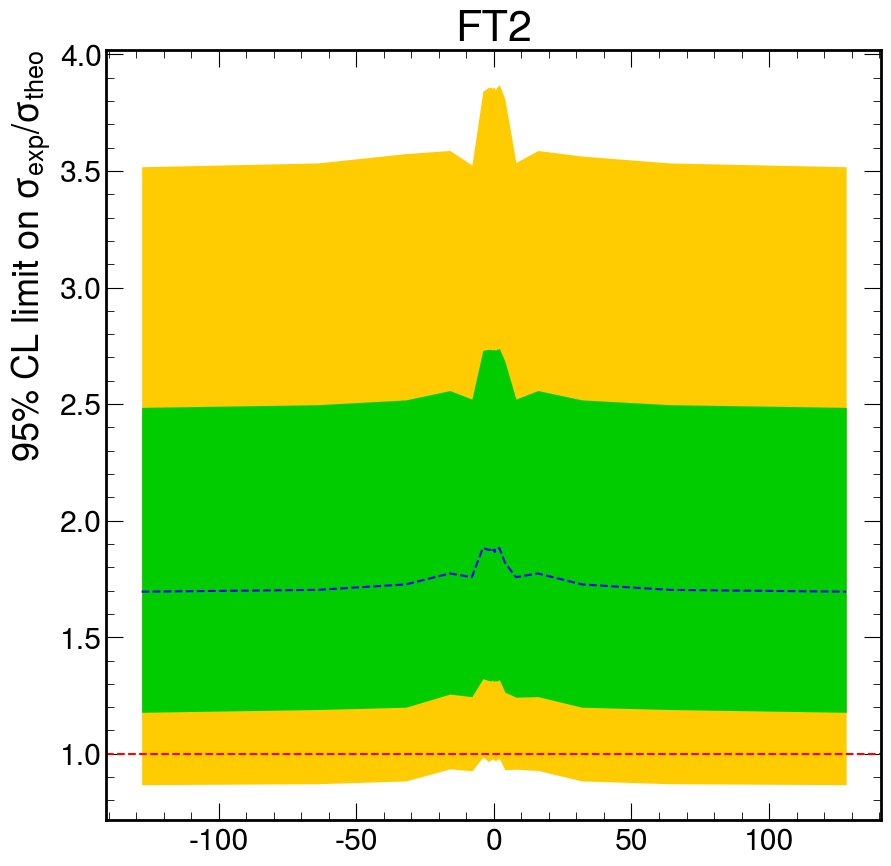

In [17]:
plotting('FT2')

(24, 2, 6)
(24, 2, 6)
(24, 2, 6)
(24, 2, 6)
(24, 2, 6)
(24, 2, 6)


error: unpack requires a buffer of 30 bytes

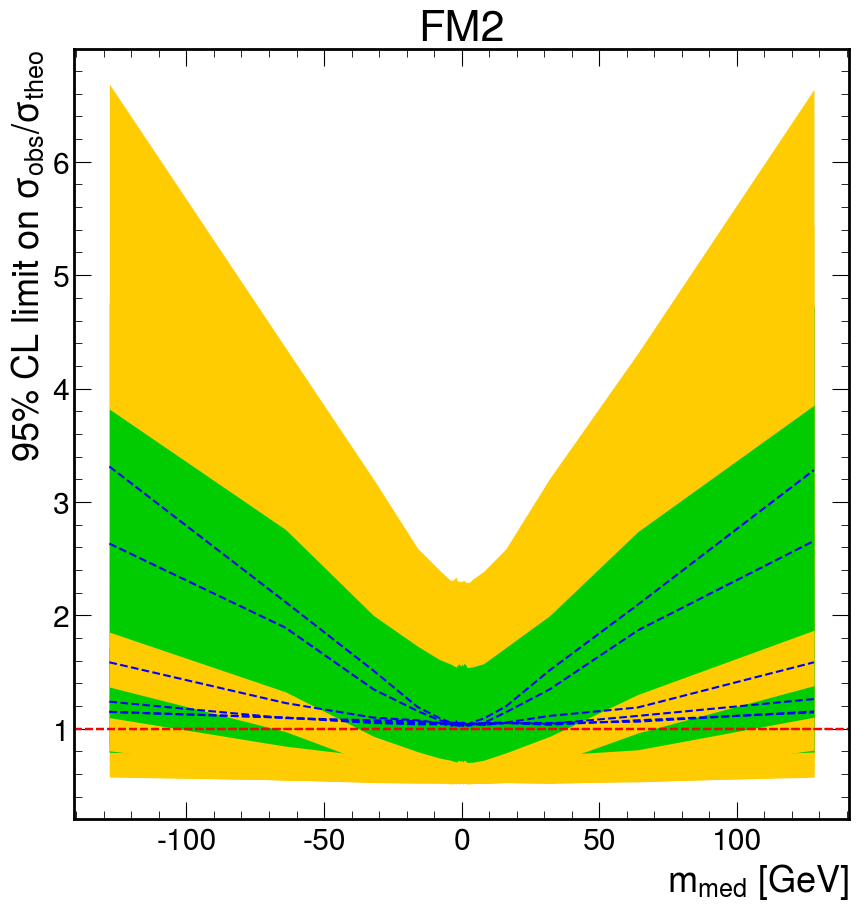

In [12]:
for i in paramlist:
    plotting(i)